<a href="https://colab.research.google.com/github/lakshuu-jay/Projects/blob/main/MakeARecommendationEngineModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

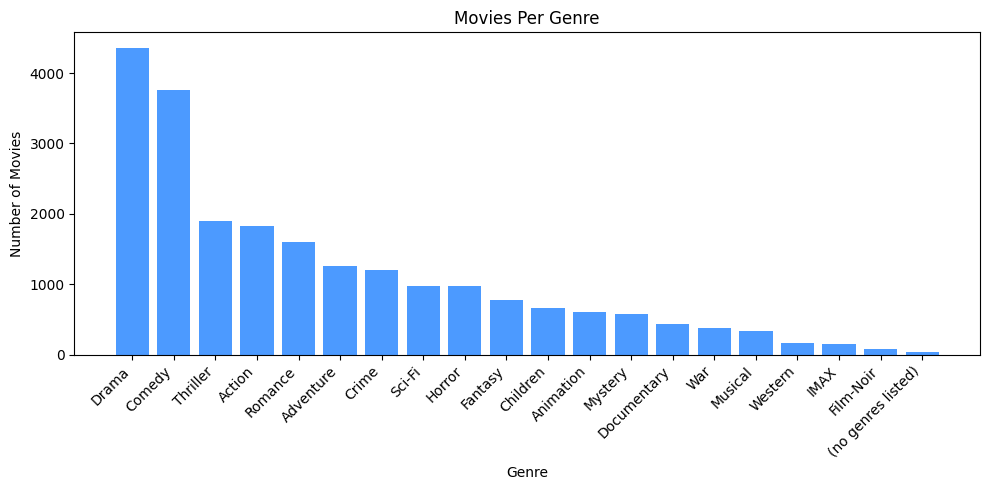

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ratings_df = pd.read_csv("ratings.csv")
ratings_df.head()

movies_df = pd.read_csv("movies.csv")
movies_df.head()

movies_df['year'] = movies_df.title.str.extract(r'(\(\d\d\d\d\))', expand=True)
movies_df['year'] = movies_df.year.str.extract(r'(\d\d\d\d)', expand=True)

movies_df['title'] = movies_df.title.str.replace(r'(\(\d\d\d\d\))', '', regex=True)
movies_df['title'] = movies_df['title'].apply(lambda x: x.strip())

movies_df.head()

movies_df['genres'] = movies_df.genres.str.split('|')

movies_copy = movies_df.copy()
for index, row in movies_df.iterrows():
    for genre in row['genres']:
        movies_copy.at[index, genre] = 1

movies_copy = movies_copy.fillna(0)
movies_copy.head()

ratings_df = ratings_df.drop(['timestamp'], axis=1)
ratings_df.head()

genre_columns = movies_copy.drop(['movieId', 'title', 'genres', 'year'], axis=1)
genre_counts = genre_columns.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values, color='#4C9AFF')
plt.title('Movies Per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


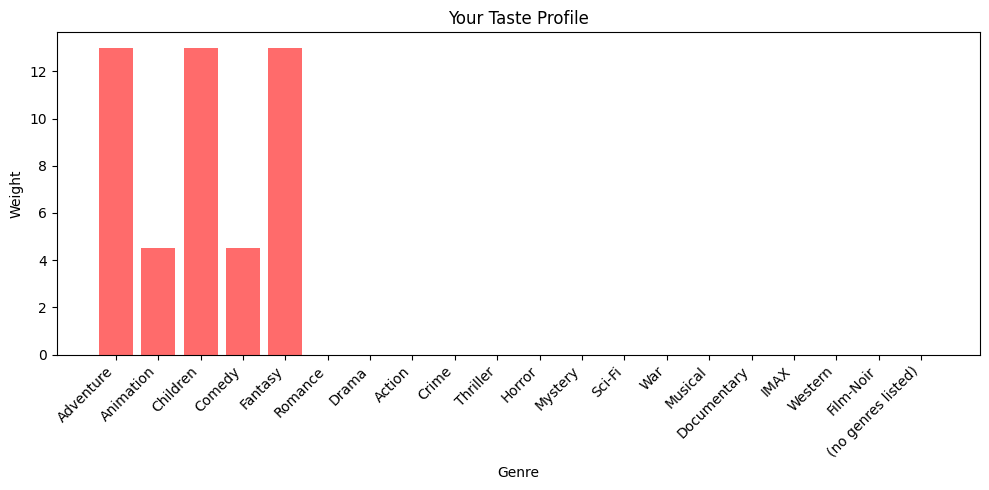

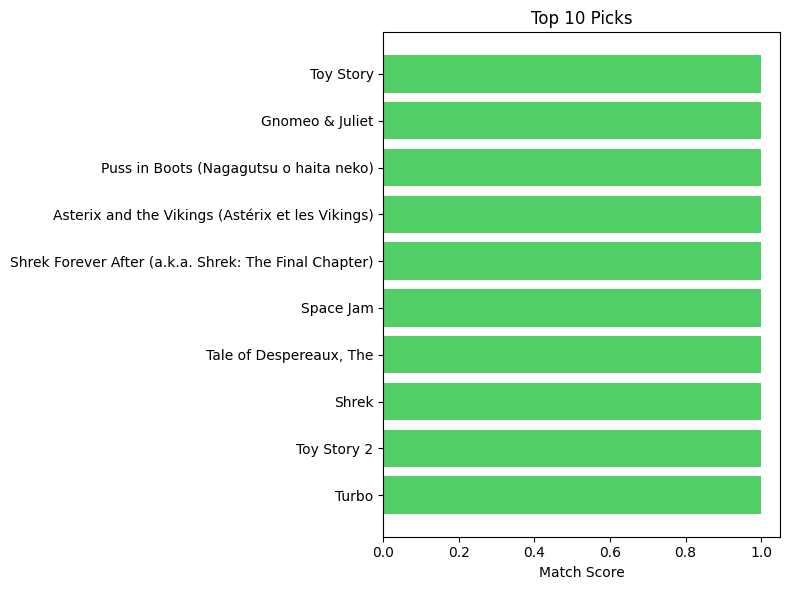

In [2]:
user_input = [
    {'title': 'Grand Slam', 'rating': 5.6},
    {'title': 'Zero', 'rating': 7},
    {'title': 'Jumanji', 'rating': 8.5},
    {'title': 'Toy Story', 'rating': 4.5},
]

movies_input = pd.DataFrame(user_input)
movies_input

input_id = movies_df[movies_df['title'].isin(movies_input['title'].tolist())]
movies_input = pd.merge(input_id, movies_input)
movies_input = movies_input.drop(['genres', 'year'], axis=1)
movies_input

movies_user = movies_copy[movies_copy['movieId'].isin(movies_input['movieId'].tolist())]
movies_user = movies_user.reset_index(drop=True)

UserGenreTable = movies_user.drop(['movieId', 'title', 'genres', 'year'], axis=1)

UserProfile = UserGenreTable.transpose().dot(movies_input['rating'])
UserProfile

plt.figure(figsize=(10, 5))
plt.bar(UserProfile.index, UserProfile.values, color='#FF6B6B')
plt.title('Your Taste Profile')
plt.xlabel('Genre')
plt.ylabel('Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

GenreTable = movies_copy.set_index(movies_copy['movieId'])
GenreTable = GenreTable.drop(['movieId', 'title', 'genres', 'year'], axis=1)

Recommendation_df = ((GenreTable * UserProfile).sum(axis=1)) / UserProfile.sum()
Recommendation_df = Recommendation_df.sort_values(ascending=False)
Recommendation_df.head()

RecommendationTable = movies_df.loc[movies_df['movieId'].isin(Recommendation_df.head(20).keys())]
RecommendationTable

top10_scores = Recommendation_df.head(10)
top10_titles = movies_df.set_index('movieId').loc[top10_scores.index]['title']

plt.figure(figsize=(8, 6))
plt.barh(top10_titles[::-1], top10_scores.values[::-1], color='#51CF66')
plt.title('Top 10 Picks')
plt.xlabel('Match Score')
plt.tight_layout()
plt.show()